In [65]:
import torch
import numpy as np
import time

In [66]:
def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(0, x)

def drelu(act: np.ndarray, grad: np.ndarray) -> np.ndarray:
    return grad * np.where(act > 0, 1, 0)

x = np.array([[10, 5, 0, -5, -10]])
grad = np.ones_like(x)
act_relu = relu(x)
grad_relu = drelu(act_relu, grad)
print(act_relu)
print(grad_relu)

[[10  5  0  0  0]]
[[1 1 0 0 0]]


In [67]:
def elu(x: np.ndarray, alpha: float=1) -> np.ndarray:
    return np.where(x>0, x, alpha * (np.exp(x) - 1))

def delu(act: np.ndarray, grad: np.ndarray, alpha: float=1) -> np.ndarray:
    return grad * np.where(act>0, 1, act + alpha)

x = np.array([[10, 5, 0, -0.5, -5, -8, -13, -17, -100]])
grad = np.ones_like(x)
alpha = 2
act_elu = elu(x, alpha=alpha)
grad_elu = delu(act_elu, grad, alpha)
print(act_elu)
print(grad_elu)

[[10.          5.          0.         -0.78693868 -1.98652411 -1.99932907
  -1.99999548 -1.99999992 -2.        ]]
[[1.00000000e+00 1.00000000e+00 2.00000000e+00 1.21306132e+00
  1.34758940e-02 6.70925256e-04 4.52065881e-06 8.27987543e-08
  0.00000000e+00]]


In [68]:
def swish(x: np.ndarray) -> np.ndarray:
    sigmoid = (1/ (1 + np.exp(-x)))
    return sigmoid, x * sigmoid

def dswish(act: np.ndarray, grad: np.ndarray, sigm: np.ndarray) -> np.ndarray:
    return grad * (act + sigm * (1 - act))

x = np.array([[10, 5, 0, -0.5, -0.7, -2, -5, -10, -100]])
grad = np.ones_like(x)

sigm, act_swish = swish(x)
grad_swish = dswish(act_swish, grad, sigm)
print(act_swish)
print(grad_swish)

[[ 9.99954602e+00  4.96653575e+00  0.00000000e+00 -1.88770334e-01
  -2.32268559e-01 -2.38405844e-01 -3.34642546e-02 -4.53978687e-04
  -3.72007598e-42]]
[[ 1.00040856e+00  1.02654743e+00  5.00000000e-01  2.60038813e-01
   1.76613217e-01 -9.07842488e-02 -2.65474324e-02 -4.08560209e-04
  -3.68287522e-42]]


In [69]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    return (1 / (1 + np.exp(-x)))

def dsigm(act: np.ndarray, grad:np.ndarray) -> np.ndarray:
    return grad * act * (1 - act)

x = np.array([[10, 5, 2, 0.5, 0, -0.5, -2, -5, -10]])

act_sigmoid = sigmoid(x)
grad_sigm = dsigm(act_sigmoid, grad)

print(act_sigmoid)
print(grad_sigm)

[[9.99954602e-01 9.93307149e-01 8.80797078e-01 6.22459331e-01
  5.00000000e-01 3.77540669e-01 1.19202922e-01 6.69285092e-03
  4.53978687e-05]]
[[4.53958077e-05 6.64805667e-03 1.04993585e-01 2.35003712e-01
  2.50000000e-01 2.35003712e-01 1.04993585e-01 6.64805667e-03
  4.53958077e-05]]


In [70]:
def softmax(x: np.ndarray) -> np.ndarray:
    max_x = np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x - max_x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def dsoftmax(act: np.ndarray, grad = np.ndarray) -> np.ndarray:
    eye = np.eye(act.shape[1])
    J = act[:, None, :] * (eye[None] - act[..., None])
    return grad @ J



In [71]:
def work_time_func(func, n_iter: int = 1000) -> float:
    start = time.perf_counter()
    for _ in range(n_iter):
        func()
    end = time.perf_counter()
    return end - start

def measure_activation_times(func_act, batch_size, vector_size, n_iter):
    x = np.random.randn(batch_size, vector_size)
    grad = np.ones((batch_size, vector_size))

    for name, (act, grad_act) in func_act.items():
        act_time = []
        grad_time = []
        for _ in range(100):
            act_time.append(work_time_func(lambda: act(x), n_iter))

            if name == "Swish":
                sigm, result = act(x)
                grad_time.append(work_time_func(lambda: grad_act(result, grad, sigm), n_iter))

            else:
                result = act(x)
                grad_time.append(work_time_func(lambda: grad_act(result, grad), n_iter))

        print(f"{name} act_time: {np.mean(act_time):.4f} ceк; der_time: {np.mean(grad_time):.4f} сек")

In [72]:
func_act = {"ReLU" : (relu, drelu), "ELU": (elu, delu), "Swish" : (swish, dswish)}
measure_activation_times(func_act, batch_size=16, vector_size=2048, n_iter=1000)

ReLU act_time: 0.0178 ceк; der_time: 0.0808 сек
ELU act_time: 0.2346 ceк; der_time: 0.0759 сек
Swish act_time: 0.2238 ceк; der_time: 0.0606 сек


# Самостоятельно

In [73]:
import keras
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from tqdm.notebook import tqdm

In [74]:
(train_data, train_target), (test_data, test_target) = keras.datasets.mnist.load_data()

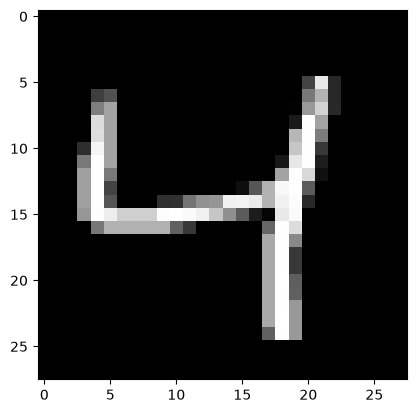

In [75]:
plt.imshow(train_data[2], cmap="grey")

In [76]:
model = torch.nn.Sequential(
    torch.nn.Linear(784, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 10),
)

In [77]:
batch_size = 128
EPOCHS = 20

train = train_data.reshape(-1, 784)/255
test = test_data.reshape(-1, 784)/255

tensor_train = torch.tensor(train, dtype=torch.float32)
tensor_trtarget = torch.tensor(train_target, dtype=torch.long)

tensor_test = torch.tensor(test, dtype=torch.float32)
tensor_tetarget = torch.tensor(test_target, dtype=torch.long)

train_dataset = TensorDataset(tensor_train, tensor_trtarget)
test_dataset = TensorDataset(tensor_test, tensor_tetarget)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

criterion = torch.nn.CrossEntropyLoss()
optim = torch.optim.SGD(model.parameters(), lr=0.1)

In [78]:
loop = tqdm(range(EPOCHS))
for epoch in loop:
    model.train()
    loss_list = []
    count_corr = 0
    for x, y in train_loader:
        optim.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)

        loss_list.append(loss)
        probs = torch.softmax(logits.detach(), dim=1)
        count_corr += torch.sum(torch.argmax(probs, axis=1) == y)

        loss.backward()
        optim.step()

    print(f"loss: {sum(loss_list)/len(loss_list)}; accuracy: {count_corr/60000}")

    loss_list = []
    count_corr = 0
    model.eval()
    for x, y in test_loader:
        with torch.no_grad():
            logits = model(x)
            loss = criterion(logits, y)
    
            loss_list.append(loss)
            probs = torch.softmax(logits.detach(), dim=1)
            count_corr += torch.sum(torch.argmax(probs, axis=1) == y)

    print(f"loss-test: {sum(loss_list)/len(loss_list)}; accuracy-test: {count_corr/10000}")



  0%|          | 0/20 [00:00<?, ?it/s]

loss: 0.5702528357505798; accuracy: 0.8599166870117188
loss-test: 0.31814339756965637; accuracy-test: 0.9093999862670898
loss: 0.29291728138923645; accuracy: 0.9164333343505859
loss-test: 0.2493300437927246; accuracy-test: 0.9283000230789185
loss: 0.24071894586086273; accuracy: 0.9319833517074585
loss-test: 0.2129683494567871; accuracy-test: 0.9380000233650208
loss: 0.20515601336956024; accuracy: 0.9424499869346619
loss-test: 0.18157030642032623; accuracy-test: 0.9470999836921692
loss: 0.17775456607341766; accuracy: 0.9495833516120911
loss-test: 0.16216078400611877; accuracy-test: 0.953000009059906
loss: 0.1567808985710144; accuracy: 0.9557499885559082
loss-test: 0.14466290175914764; accuracy-test: 0.9587000012397766
loss: 0.13973474502563477; accuracy: 0.9605333209037781
loss-test: 0.13296261429786682; accuracy-test: 0.9610000252723694
loss: 0.1257266253232956; accuracy: 0.9644333124160767
loss-test: 0.12193072587251663; accuracy-test: 0.9653000235557556
loss: 0.11485829204320908; acc